In [1]:
from abc import ABC, abstractmethod
from collections import namedtuple
from dataclasses import dataclass
from pprint import pformat

import carla
import numpy as np
import torch

from PCLA import location_to_waypoint
from pcla_functions.spawn_points import draw_spawn_points
from viz_map import MapVisualization

In [2]:
TOWN = "Town02"
HOST = "localhost"
PORT = 2000

In [3]:
client = carla.Client(HOST, PORT, worker_threads=1)
client.set_timeout(30.0)
client.load_world(TOWN)


# Set the spectator with our transform
world = client.get_world()
settings = world.get_settings()
settings.synchronous_mode = False  # Disables synchronous mode
world.apply_settings(settings)


carla_map = world.get_map()
carla_map.save_to_disk(f"./{TOWN}.xodr")
with open(f"./{TOWN}.xodr", "r") as f:
    xodr_content = f.read()
    carla_map = carla.Map(carla_map.name, xodr_content)

In [4]:
landmarks = carla_map.get_all_landmarks()
locations_objs = [landmark.transform.location for landmark in landmarks]
locations = np.array([[loc.x, loc.y, loc.z] for loc in locations_objs])


# Get min and max x coords
MIN_X = np.min(locations[:, 0])
MAX_X = np.max(locations[:, 0])

# Get min and max y coords
MIN_Y = np.min(locations[:, 1])
MAX_Y = np.max(locations[:, 1])

# Get min and max z coords
MIN_Z = np.min(locations[:, 2])
MAX_Z = np.max(locations[:, 2])

print(
    f"Feature ranges: x: {MIN_X:2f} to {MAX_X:2f}, y: {MIN_Y:2f} to {MAX_Y:2f}, z: {MIN_Z:2f} to {MAX_Z:2f}"
)

spec_x = (MAX_X - MIN_X) / 2
spec_y = (MAX_Y - MIN_Y) / 2
bev_transform = carla.Transform(
    carla.Location(x=spec_x, y=spec_y, z=300), carla.Rotation(pitch=-90, yaw=0, roll=0)
)
world.get_spectator().set_transform(bev_transform)

Feature ranges: x: -10.080016 to 196.319992, y: 102.939995 to 309.410034, z: -0.699043 to 0.360000


In [5]:
def loc_to_str(loc):
    return f"({loc.x:.2f}, {loc.y:.2f}, {loc.z:.2f})"


## Test points sampling

In [6]:
@dataclass
class NumericalFeature:
    name: str
    low: float
    high: float


class ProblemDomain(ABC):
    def __init__(
        self,
        features: list[NumericalFeature],
    ) -> None:
        self._features = features
        self._low = torch.tensor([f.low for f in features], dtype=torch.float32)
        self._high = torch.tensor([f.high for f in features], dtype=torch.float32)

    @property
    def n_dims(self) -> int:
        return len(self._features)

    @property
    def feature_names(self) -> list[str]:
        return [f.name for f in self._features]

    @property
    def low(self) -> torch.Tensor:
        return self._low

    @property
    def high(self) -> torch.Tensor:
        return self._high

    @property
    def features(self) -> list[NumericalFeature]:
        return self._features

    def bounds(self) -> tuple[torch.Tensor, torch.Tensor]:
        return (self._low, self._high)

    def sample(self) -> torch.Tensor:
        return torch.rand(self.n_dims) * (self._high - self._low) + self._low

    @abstractmethod
    def is_valid(self, x: torch.Tensor) -> bool:
        raise NotImplementedError

    def to_dict(self, x: torch.Tensor) -> dict:
        return {f.name: x[i].item() for i, f in enumerate(self._features)}

    def to_tensor(self, scenario_dict: dict) -> torch.Tensor:
        return torch.tensor([scenario_dict[f.name] for f in self._features], dtype=torch.float32)

    def __repr__(self) -> str:
        return f"{self.__class__.__name__}(\n  features={pformat(self._features, indent=4)}\n)"


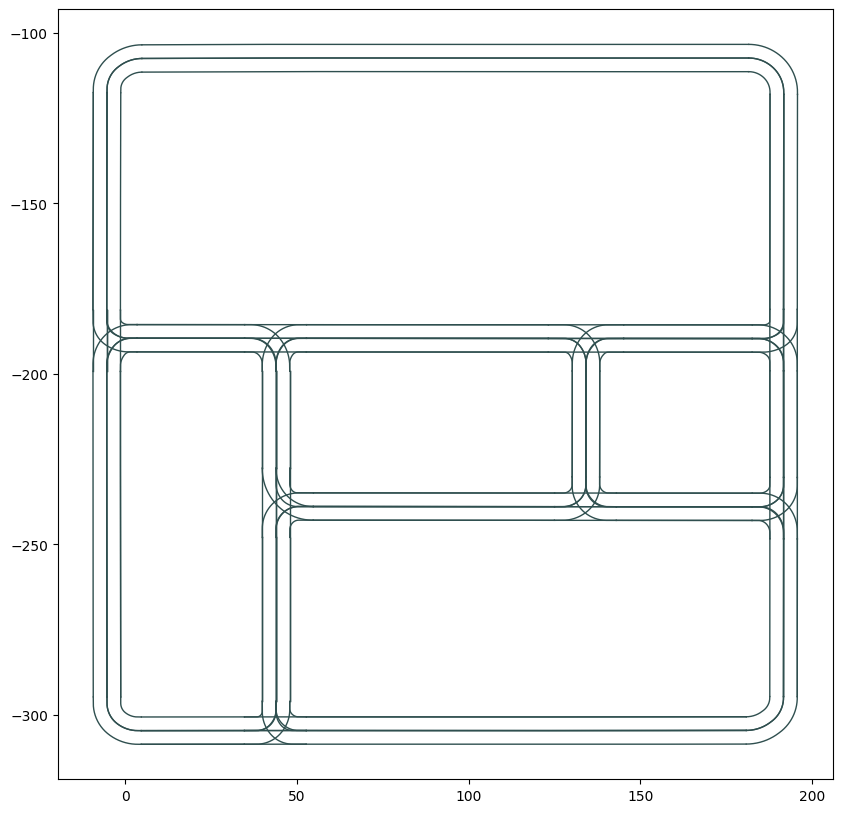

In [7]:
viz = MapVisualization(carla_map)
viz.draw_roads()
# viz.draw_spawn_points()
viz.destroy()
ax = viz.ax
fig = viz.fig

## Single point domain

In [8]:
class CarlaPointProblemDomain(ProblemDomain):
    def __init__(
        self,
    ) -> None:
        feat = []
        feat.append(NumericalFeature("start_x", MIN_X, MAX_X))
        feat.append(NumericalFeature("start_y", MIN_Y, MAX_Y))
        super().__init__(feat)

    def check_location(self, carla_loc: carla.Location) -> bool:
        PROJECT = False
        wp = carla_map.get_waypoint(carla_loc, project_to_road=PROJECT, lane_type=carla.LaneType.Driving)
        if wp and not wp.is_junction:
            location = wp.transform.location
            print(f"Waypoint found for location: {carla_loc!s} at {location!s}")
            return True
            # world.debug.draw_string(location, "o", life_time=60.0, persistent_lines=True)
        else:
            print(f"No waypoint found for location: {carla_loc!s}")
            return False

    def is_valid(self, x) -> bool:
        start_loc = carla.Location(float(x[0]), float(x[1]), 0.0)
        # goal_loc = carla.Location(float(x[2]), float(x[3]), 0.0)
        return self.check_location(start_loc)  # and self.check_location(goal_loc)


domain = CarlaPointProblemDomain()


In [9]:
# N_POINTS = 1000
# for _ in range(N_POINTS):
#     x = domain.sample()
#     loc = carla.Location(x=x[0].item(), y=x[1].item(), z=0.0)
#     plot_x = x[0].item()
#     plot_y = -x[1].item()
#     PROJECT = False
#     wp = carla_map.get_waypoint(loc, project_to_road=PROJECT, lane_type=carla.LaneType.Driving)
#     if wp and not wp.is_junction:
#         wp_location = wp.transform.location
#         print(f"Waypoint found for location: {loc_to_str(loc)} at {loc_to_str(wp_location)}")
#         color = "green"
#         ax.scatter(plot_x, plot_y, color=color, s=10, label="Sampled Point")
#         world.debug.draw_string(
#             wp_location, "o", life_time=60.0, persistent_lines=True, color=carla.Color(0, 150, 0)
#         )
#         ax.arrow(plot_x, plot_y, wp_location.x - plot_x, -wp_location.y - plot_y)

#     else:
#         print(f"Point {loc_to_str(loc)} not valid")
#         color = "red"
#         ax.scatter(plot_x, plot_y, color=color, s=10, label="Sampled Point")
#         world.debug.draw_string(loc, "x", life_time=60.0, persistent_lines=True, color=carla.Color(255, 0, 0))

# fig.tight_layout()
# fig.savefig(f"./{TOWN}_sampled_points.pdf", format="pdf", bbox_inches="tight")
# fig

In [10]:
domain = CarlaPointProblemDomain()
valid_points = []
MIN_DISTANCE = 25.0
MAX_DISTANCE = 100.0
valid, total = 0, 0
while len(valid_points) < 5:
    x = domain.sample()
    if domain.is_valid(x):
        if not valid_points:
            valid_points.append(x)
        else:
            dist_to_previous = torch.dist(x, valid_points[-1])
            if MIN_DISTANCE <= dist_to_previous <= MAX_DISTANCE:
                valid_points.append(x)
                valid += 1
    total += 1

No waypoint found for location: Location(x=64.575134, y=263.851105, z=0.000000)
No waypoint found for location: Location(x=66.398781, y=178.090668, z=0.000000)
No waypoint found for location: Location(x=12.374949, y=263.800873, z=0.000000)
No waypoint found for location: Location(x=46.642681, y=130.107742, z=0.000000)
No waypoint found for location: Location(x=177.223679, y=243.889191, z=0.000000)
Waypoint found for location: Location(x=119.226624, y=188.537170, z=0.000000) at Location(x=119.227036, y=187.606888, z=0.000000)
Waypoint found for location: Location(x=59.698265, y=235.865784, z=0.000000) at Location(x=59.697655, y=236.879807, z=0.000000)
No waypoint found for location: Location(x=137.808960, y=116.171791, z=0.000000)
Waypoint found for location: Location(x=177.992584, y=303.150635, z=0.000000) at Location(x=177.992325, y=302.503876, z=0.000000)
No waypoint found for location: Location(x=64.945068, y=162.329315, z=0.000000)
No waypoint found for location: Location(x=49.0293

In [11]:
valid_points

[tensor([119.2266, 188.5372]),
 tensor([ 59.6983, 235.8658]),
 tensor([ -7.3542, 209.3156]),
 tensor([ 45.5183, 218.2210]),
 tensor([ -8.0415, 158.7416])]

In [12]:
valid_point_locations = [carla.Location(x=float(x[0]), y=float(x[1]), z=0.0) for x in valid_points]
valid_point_locations

In [13]:
from itertools import pairwise

from leaderboard_codes.global_route_planner import GlobalRoutePlanner
from leaderboard_codes.global_route_planner_dao import GlobalRoutePlannerDAO


def interpolate_route(
    amap: carla.Map,
    starting_location: carla.Location,
    ending_location: carla.Location,
    distance=2,
    color=None,
):
    # This function is used to generate waypoints between two locations
    dao = GlobalRoutePlannerDAO(amap, distance)
    grp = GlobalRoutePlanner(dao)
    grp.setup()
    waypoints_tuples = grp.trace_route(starting_location, ending_location)
    waypoints = [wp[0] for wp in waypoints_tuples]

    if color:
        for wp in waypoints:
            loc = wp.transform.location
            world.debug.draw_string(loc, "o", life_time=10.0, persistent_lines=True, color=color)

    return waypoints

In [14]:
carla_colors = [
    carla.Color(20, 0, 0),
    carla.Color(0, 20, 0),
    carla.Color(0, 0, 20),
    carla.Color(20, 20, 0),
]

results = [
    interpolate_route(carla_map, a, b, color=c)
    for (a, b), c in zip(pairwise(valid_point_locations), carla_colors)
]
waypoints = [x for xs in results for x in xs]

In [15]:
locations = [wp.transform.location for wp in waypoints]
locations_xyz = torch.tensor([[loc.x, loc.y, loc.z] for loc in locations])
locations_xyz

tensor([[119.1809, 187.6069,   0.0000],
        [117.1809, 187.6060,   0.0000],
        [115.1809, 187.6050,   0.0000],
        ...,
        [ -7.4364, 151.5554,   0.0000],
        [ -7.4409, 153.5554,   0.0000],
        [ -7.4454, 155.5554,   0.0000]])

In [16]:
from PCLA import route_maker

route_maker(waypoints=waypoints, savePath="test_routes.xml")

In [34]:
from itertools import pairwise
from pathlib import Path

import carla
import torch
from shapely.geometry import LineString, Point


class CarlaRouteProblemDomain(ProblemDomain):
    N_WAYPOINTS = 5
    MAX_DISTANCE_BETWEEN_WAYPOINTS = 200.0
    INTERPOLATION_DISTANCE = 2  # meters
    ROUTE_WIDTH = 1.8  # half-width (m) of the buffered "road strip" used for visualization
    MAP_FILE = "data/carla/Town02.xodr"

    def __init__(self, xodr_text: str = None) -> None:

        self.initialize_carla_map(xodr_text)
        self.initialize_map_contrains()

        feat = self.initialize_features()
        super().__init__(feat)

    def initialize_carla_map(self, xodr_text: str = None) -> None:
        if xodr_text is None:
            repo_root = Path(__file__).resolve().parents[3]
            xodr_path = repo_root / Path(self.MAP_FILE)
            xodr_text = xodr_path.read_text()
            map_name = Path(self.MAP_FILE).stem
            self.carla_map = carla.Map(map_name, xodr_text)
        else:
            self.carla_map = carla.Map("Town02", xodr_text)

        dao = GlobalRoutePlannerDAO(self.carla_map, self.INTERPOLATION_DISTANCE)
        self.grp = GlobalRoutePlanner(dao)
        self.grp.setup()

    def initialize_map_contrains(self):
        landmarks = self.carla_map.get_all_landmarks()
        locations_objs = [landmark.transform.location for landmark in landmarks]
        locations = torch.tensor([[loc.x, loc.y, loc.z] for loc in locations_objs])
        self.MIN_X = torch.min(locations[:, 0]).item()
        self.MAX_X = torch.max(locations[:, 0]).item()

        self.MIN_Y = torch.min(locations[:, 1]).item()
        self.MAX_Y = torch.max(locations[:, 1]).item()

        self.MIN_Z = torch.min(locations[:, 2]).item()
        self.MAX_Z = torch.max(locations[:, 2]).item()
        print("Domain initialized with constraints:")
        print(f"  X: {self.MIN_X} to {self.MAX_X}")
        print(f"  Y: {self.MIN_Y} to {self.MAX_Y}")
        print(f"  Z: {self.MIN_Z} to {self.MAX_Z}")

    def initialize_features(self):
        features = []
        for waypoint_idx in range(self.N_WAYPOINTS):
            features.append(NumericalFeature(f"wp_{waypoint_idx}_x", self.MIN_X, self.MAX_X))
            features.append(NumericalFeature(f"wp_{waypoint_idx}_y", self.MIN_Y, self.MAX_Y))
            features.append(NumericalFeature(f"wp_{waypoint_idx}_z", self.MIN_Z, self.MAX_Z))

        # TODO Add weather conditions as features
        return features

    def interpolate_route(self, starting_location: carla.Location, ending_location: carla.Location):
        # This function is used to generate waypoints between two locations
        waypoints_tuples = self.grp.trace_route(starting_location, ending_location)
        waypoints = [wp[0] for wp in waypoints_tuples]
        return waypoints

    def get_scenario_shapes(self, scenario: dict):
        """Scenario shape for visualization — the routed path as a buffered road strip.

        Returns a single shapely Polygon (a ``LineString`` of the interpolated
        route buffered by ``ROUTE_WIDTH``). This mirrors what ``is_valid`` checks
        (the same per-pair ``interpolate_route`` calls), so the drawn shape matches
        the semantics used to accept/reject a scenario.
        """
        locations = [
            carla.Location(scenario[f"wp_{i}_x"], scenario[f"wp_{i}_y"], scenario[f"wp_{i}_z"])
            for i in range(self.N_WAYPOINTS)
        ]

        route_points = []
        for a, b in pairwise(locations):
            try:
                route = self.interpolate_route(a, b)
            except Exception:
                route = []
            if route:
                route_points.extend(wp.transform.location for wp in route)

        # Degenerate fallback so the shape is never empty for plotting.
        if not route_points:
            return Point(locations[0].x, locations[0].y).buffer(self.ROUTE_WIDTH)

        line = LineString([(p.x, p.y) for p in route_points])
        return line.buffer(self.ROUTE_WIDTH, cap_style=2)

    def is_valid(self, x, debug: bool = False) -> bool:
        # Check if each point can be placed on the road and is not junction
        locations = []
        for waypoint_idx in range(self.N_WAYPOINTS):
            curr_point = [x[waypoint_idx * 3], x[waypoint_idx * 3 + 1], x[waypoint_idx * 3 + 2]]
            locations.append(carla.Location(float(curr_point[0]), float(curr_point[1]), float(curr_point[2])))

        interpolation_results = [self.interpolate_route(a, b) for a, b in pairwise(locations)]
        # Validate route finding
        for i, results in enumerate(interpolation_results):
            if len(results) < 2:
                if debug:
                    print(
                        f"Path finding between waypoint {i} and {i + 1} failed: only {len(results)} waypoints found"
                    )
                return False
        interpolated_waypoints = [wp for results in interpolation_results for wp in results]
        estimated_total_distance = len(interpolated_waypoints) * self.INTERPOLATION_DISTANCE
        # Check if total route distance is within the specified range
        max_allowed_distance = self.N_WAYPOINTS * self.MAX_DISTANCE_BETWEEN_WAYPOINTS
        valid_distance = max_allowed_distance > estimated_total_distance

        if not valid_distance and debug:
            print(f"Distance {estimated_total_distance:.2f} is higher than {max_allowed_distance:.2f}")

        return valid_distance


In [35]:
domain = CarlaRouteProblemDomain(xodr_text=xodr_content)
# invalid_a, invalid_b = carla.Location(x=-100, y=220.0, z=0.0), carla.Location(x=100, y=200.0, z=0.0)

# # domain.get_waypoint_of_coordinates(0, 220.0, 0.0, debug=True)
# points = domain.interpolate_route(invalid_a, invalid_b)
# [loc_to_str(loc.transform.location) for loc in points]

# x = domain.sample()

Domain initialized with constraints:
  X: -10.080016136169434 to 196.3199920654297
  Y: 102.93999481201172 to 309.4100341796875
  Z: -0.6990432739257812 to 0.36000001430511475


In [36]:
search_time = 60
import time

start_time = time.time()

N_VALID_SAMPLES = 100
total = 0
valid_samples = []
while len(valid_samples) < N_VALID_SAMPLES:
    total += 1
    x = domain.sample()
    # print(x)
    if domain.is_valid(x, debug=True):
        print("Valid sample found:", x)
        valid_samples.append(x)

end_time = time.time()

Path finding between waypoint 0 and 1 failed: only 0 waypoints found
Path finding between waypoint 0 and 1 failed: only 0 waypoints found
Distance 1906.00 is higher than 1000.00
Distance 1332.00 is higher than 1000.00
Distance 1282.00 is higher than 1000.00
Distance 1308.00 is higher than 1000.00
Path finding between waypoint 0 and 1 failed: only 0 waypoints found
Distance 1496.00 is higher than 1000.00
Path finding between waypoint 0 and 1 failed: only 0 waypoints found
Path finding between waypoint 0 and 1 failed: only 0 waypoints found
Path finding between waypoint 0 and 1 failed: only 0 waypoints found
Path finding between waypoint 0 and 1 failed: only 0 waypoints found
Path finding between waypoint 2 and 3 failed: only 0 waypoints found
Distance 2186.00 is higher than 1000.00
Path finding between waypoint 1 and 2 failed: only 1 waypoints found
Distance 1674.00 is higher than 1000.00
Distance 1882.00 is higher than 1000.00
Path finding between waypoint 0 and 1 failed: only 0 waypoi

In [37]:
print(
    f"Found {len(valid_samples)} valid samples in {total} attempts ratio: {len(valid_samples) / total * 100:.2g}%, took {end_time - start_time:.2f} seconds"
)

Found 100 valid samples in 2687 attempts ratio: 3.7%, took 10.71 seconds


In [21]:
valid_route = valid_samples[2]
domain.to_dict(valid_route)

{'wp_0_x': -5.914891242980957,
 'wp_0_y': 103.1961441040039,
 'wp_0_z': 0.02574610710144043,
 'wp_1_x': 144.18572998046875,
 'wp_1_y': 203.44158935546875,
 'wp_1_z': -0.14751416444778442,
 'wp_2_x': 27.188980102539062,
 'wp_2_y': 221.48822021484375,
 'wp_2_z': -0.42274099588394165,
 'wp_3_x': 61.830322265625,
 'wp_3_y': 173.030029296875,
 'wp_3_z': 0.12692564725875854,
 'wp_4_x': 171.7056884765625,
 'wp_4_y': 307.1391296386719,
 'wp_4_z': -0.40536224842071533}

In [39]:
route_locations = [
    carla.Location(
        x=float(valid_route[i * 3]),
        y=float(valid_route[i * 3 + 1]),
        z=float(valid_route[i * 3 + 2]),
    )
    for i in range(domain.N_WAYPOINTS)
]
route_waypoints = [
    interpolate_route(carla_map, start, end, color=c)
    for (start, end), c in zip(pairwise(route_locations), carla_colors)
]
interpolated_waypoints = [wp for results in route_waypoints for wp in results]


In [33]:
route_maker(interpolated_waypoints, "valid_route.xml")

In [24]:
# interpolated_waypoints = [loc_to_str(wp.transform.location) for results in route_waypoints for wp in results]
# interpolated_waypoints


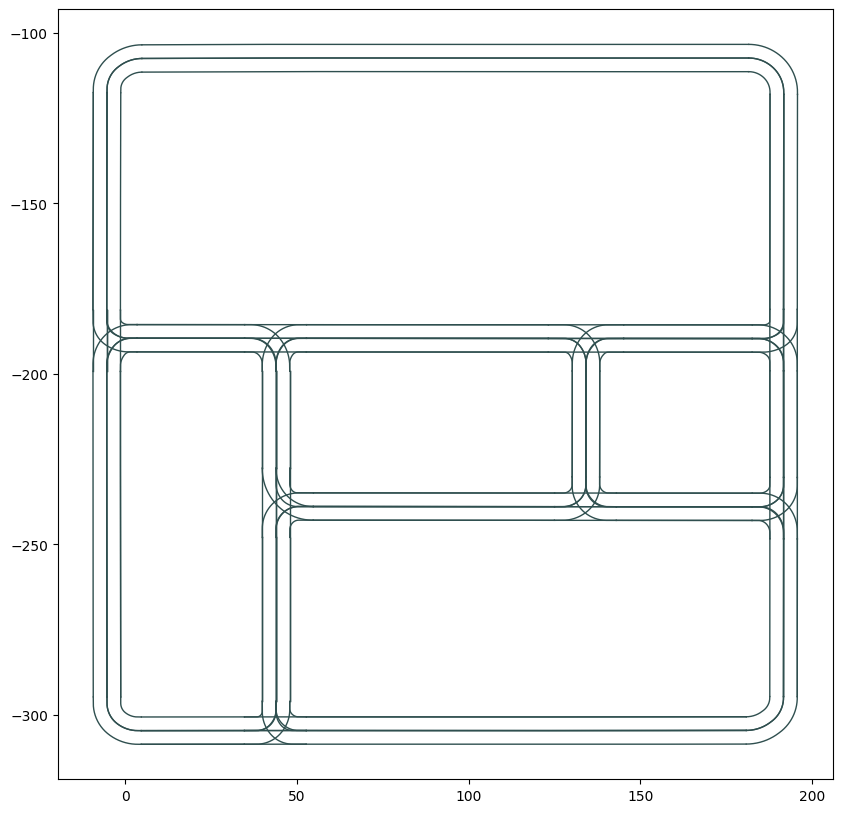

In [27]:
viz = MapVisualization(carla_map)
viz.draw_roads()
# fig


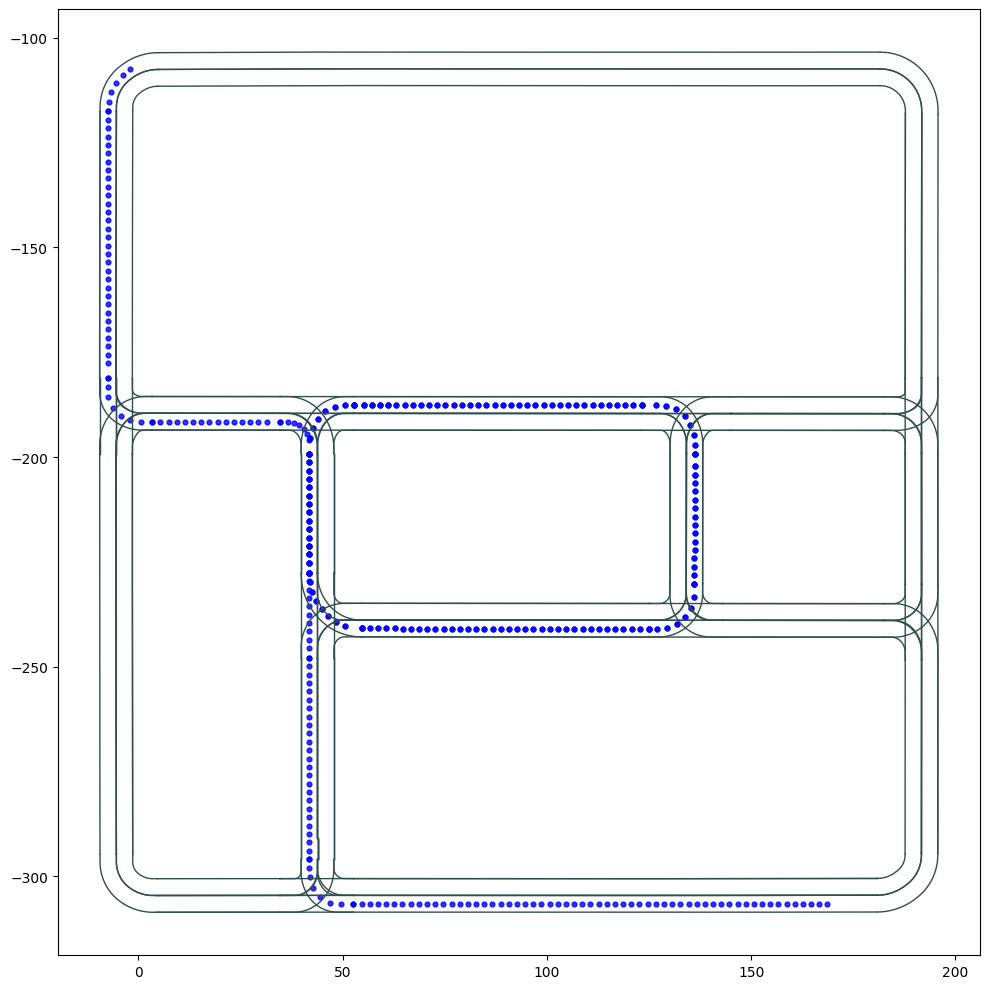

In [28]:
for wp in interpolated_waypoints:
    loc = wp.transform.location
    ax.scatter(loc.x, -loc.y, s=12, color="blue", alpha=0.8)

fig.tight_layout()
fig

In [38]:
# marker = carla_colors[0].lower()[0]
world = client.get_world()
traffic_lights = world.get_actors().filter("*traffic.traffic_light*")

for tl in traffic_lights:
    tl.set_state(carla.TrafficLightState.Green)
    tl.set_green_time(9999.0)
    tl.freeze(True)

print(f"Set {len(traffic_lights)} traffic lights to green.")


Set 24 traffic lights to green.
